In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


In [3]:
# Load Dataset
df = pd.read_csv('AEP_hourly.csv')

In [3]:
# View Dataset
print(df.head())

              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


In [4]:
# Rename Columns
df.columns = ['Datetime', 'Energy']

In [5]:
# Convert Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [6]:
# Sort Values
df = df.sort_values('Datetime')

In [7]:
# Set Datetime Index
df.set_index('Datetime', inplace=True)

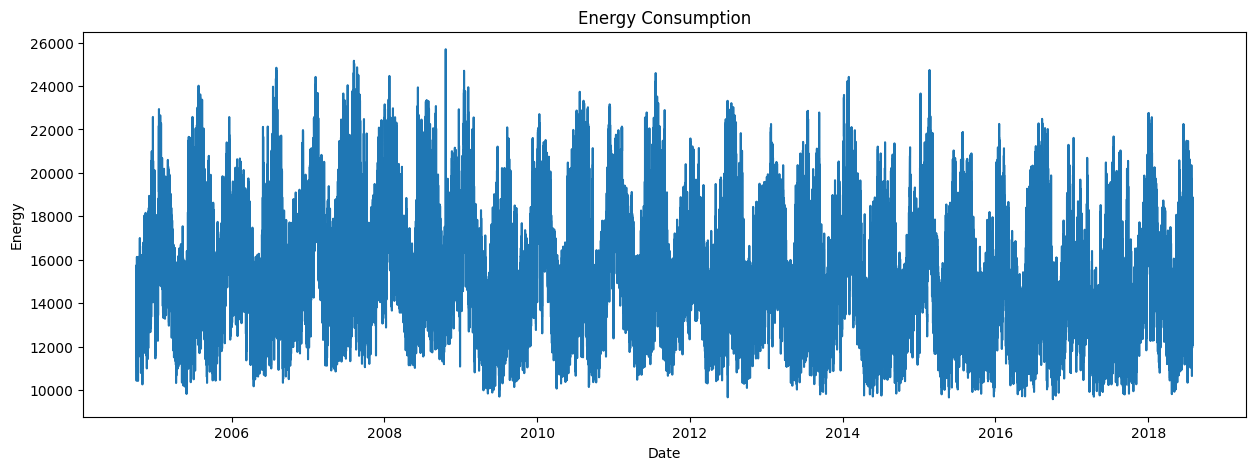

In [8]:
# Plot Dataset
plt.figure(figsize=(15,5))
plt.plot(df['Energy'])
plt.title('Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy')
plt.show()


In [8]:
# Normalize Data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Energy']])

In [9]:
# Create Sequences
X = []
y = []

sequence_length = 24

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

In [10]:
# Reshape for LSTM

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [11]:
# Train Test Split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [12]:
# Build LSTM Model
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

c:\Users\Shailesh Yadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 0.0031 - val_loss: 4.8878e-04
Epoch 2/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 103s 34ms/step - loss: 7.2598e-04 - val_loss: 2.7297e-04
Epoch 3/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 5.7128e-04 - val_loss: 2.2228e-04
Epoch 4/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5.2333e-04 - val_loss: 2.1653e-04
Epoch 5/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 53s 18ms/step - loss: 4.8319e-04 - val_loss: 2.1709e-04
Epoch 6/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 4.5294e-04 - val_loss: 2.0002e-04
Epoch 7/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 93s 31ms/step - loss: 4.3986e-04 - val_loss: 1.7626e-04
Epoch 8/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - loss: 4.1386e-04 - val_loss: 2.0338e-04
Epoch 9/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 3.9030e-04 - val_loss: 1.8227e-04
Epoch 10/10
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 3.6995e-04 - val_loss: 2.4441e-04


In [15]:
# Predictions
predictions = model.predict(X_test)

758/758 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [16]:
# Inverse Transform

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


In [17]:
# Evaluation
mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("\nModel Performance")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)



Model Performance
------------------------
MAE : 204.32401006765463
MSE : 63463.66671323992
RMSE: 251.9199609265608


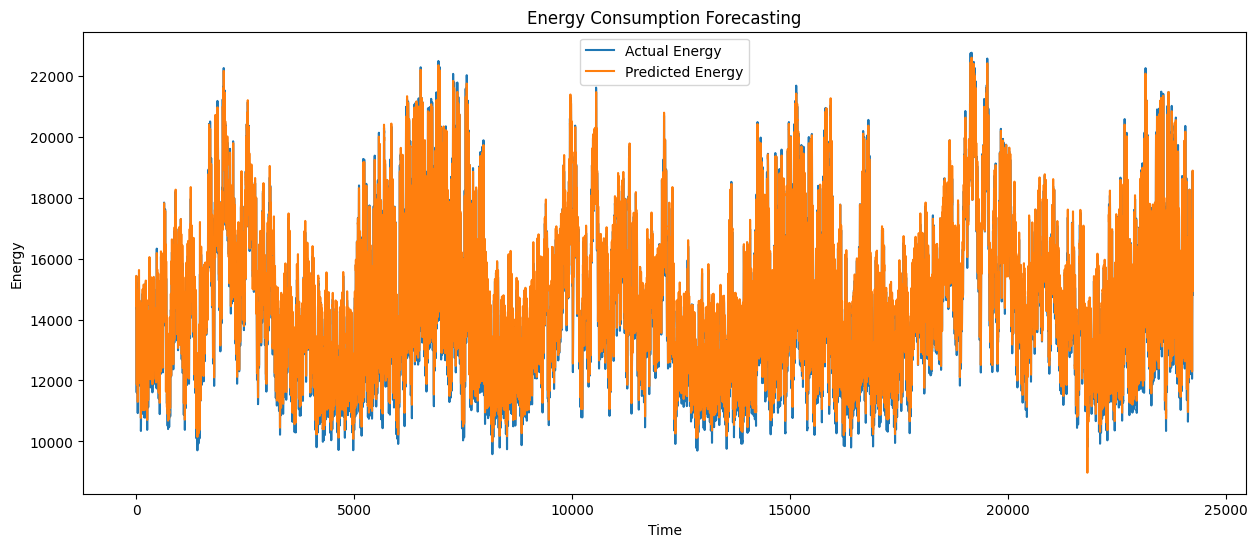

In [18]:
# Plot Predictions

plt.figure(figsize=(15,6))

plt.plot(y_test_actual, label='Actual Energy')

plt.plot(predictions, label='Predicted Energy')

plt.title('Energy Consumption Forecasting')

plt.xlabel('Time')

plt.ylabel('Energy')

plt.legend()

plt.show()


In [19]:
# Save Model

model.save("energy_forecasting_model.keras")

print("\nModel Saved Successfully!")


Model Saved Successfully!
